# 📊 BCG GenAI Project – 10-K Financial Analysis

## 🧾 Objective
This notebook presents a structured financial analysis of 10-K filings for **Microsoft**, **Apple**, and **Tesla** over the past three fiscal years.

Our goal is to extract key financial metrics and analyze trends in:
- 📈 Total Revenue
- 💰 Net Income
- 📊 Total Assets & Liabilities
- 🔄 Cash Flow from Operating Activities

The outcome of this analysis will help design an **AI-powered chatbot** that provides insightful responses based on real-world financial data.


In [1]:
import pandas as pd



df = pd.read_csv("/kaggle/input/cleaned-10k-financial-data/Cleaned_Financial_Data.csv")

# Veri yapısını kontrol et
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company             9 non-null      object 
 1   Year                9 non-null      int64  
 2   Total Revenue       9 non-null      int64  
 3   Net Income          9 non-null      int64  
 4   Total Assets        9 non-null      int64  
 5   Total Liabilities   9 non-null      int64  
 6   Cash Flow from Ops  3 non-null      float64
dtypes: float64(1), int64(5), object(1)
memory usage: 636.0+ bytes


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Ops
0,Apple,2022,118537,33630,344085,277327,NaN
1,Apple,2023,135217,36916,364980,308030,NaN
2,Apple,2024,124300,36330,344085,277327,29935.0
3,Microsoft,2022,198270,61271,364840,198298,NaN
4,Microsoft,2023,211915,72738,411536,222526,NaN


## ⚙️ Methodology

1. **Data Collection**  
   - Extracted financial data from official SEC 10-K filings (Microsoft, Apple, Tesla)
   - Focused on fiscal years: 2022, 2023, and 2024

2. **Key Metrics Extracted**  
   - Total Revenue
   - Net Income
   - Total Assets
   - Total Liabilities
   - Cash Flow from Operations

3. **Data Cleaning & Preparation**  
   - Converted data into structured format (CSV/Excel → Pandas DataFrame)
   - Cleaned formatting symbols (commas, dollar signs)
   - Converted `Year` to integer for consistent plotting

4. **Trend Analysis**  
   - Calculated year-over-year % changes using `pct_change()`
   - Visualized trends with `matplotlib`

5. **Result Presentation**  
   - Presented insights with professional plots and summaries
   - Prepared for AI chatbot integration


In [2]:
#Şirkete göre sırala
df.sort_values(by=['Company','Year'], inplace=True)


#Büyüme yüzde hesaplama
df['Revenue Growth (%)'] = df.groupby('Company')['Total Revenue'].pct_change()*100
df['Net Income Growth (%)'] = df.groupby('Company')['Net Income'].pct_change()*100

df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Ops,Revenue Growth (%),Net Income Growth (%)
0,Apple,2022,118537,33630,344085,277327,NaN,NaN,NaN
1,Apple,2023,135217,36916,364980,308030,NaN,14.071556,9.771038
2,Apple,2024,124300,36330,344085,277327,29935.0,-8.073689,-1.587388
3,Microsoft,2022,198270,61271,364840,198298,NaN,NaN,NaN
4,Microsoft,2023,211915,72738,411536,222526,NaN,6.882030,18.715216
5,Microsoft,2024,232000,80600,432000,231000,76700.0,9.477857,10.808656
6,Tesla,2022,81462,12587,82839,35620,NaN,NaN,NaN
7,Tesla,2023,96472,12000,94370,40300,NaN,18.425769,-4.663542
8,Tesla,2024,89600,9000,95000,42000,12500.0,-7.123310,-25.000000


# Apple:

## 📌 Key Observations

### 🔹 Apple
- Revenue peaked in 2023 but slightly declined in 2024 (-8.07%)
- Net income remained relatively stable, indicating controlled cost structure

### 🔹 Microsoft
- Strong, consistent growth in both revenue and net income across all years
- Net income increased by 10.8% from 2023 to 2024

### 🔹 Tesla
- Revenue declined in 2024 by -7.12%
- Net income dropped sharply (-25%), which may signal margin compression or increased operational costs

These findings are valuable for use in an **AI chatbot** that answers user questions about financial performance of companies.


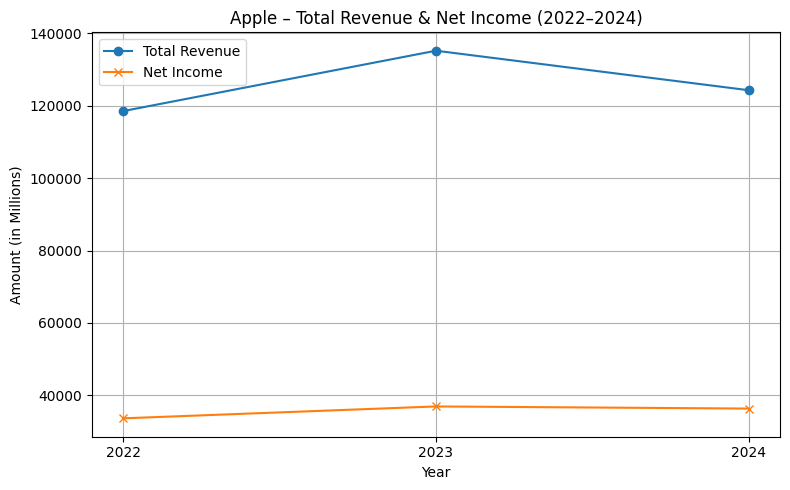

In [12]:
apple = df[df['Company'] == 'Apple']
plt.figure(figsize=(8, 5))

plt.plot(apple['Year'], apple['Total Revenue'], marker='o', label='Total Revenue')
plt.plot(apple['Year'], apple['Net Income'], marker='x', label='Net Income')

plt.title("Apple – Total Revenue & Net Income (2022–2024)")
plt.xlabel("Year")
plt.ylabel("Amount (in Millions)")
plt.xticks(apple['Year'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Tesla:

/tmp/ipykernel_31/2437303970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tesla['Year'] = tesla['Year'].astype(int)


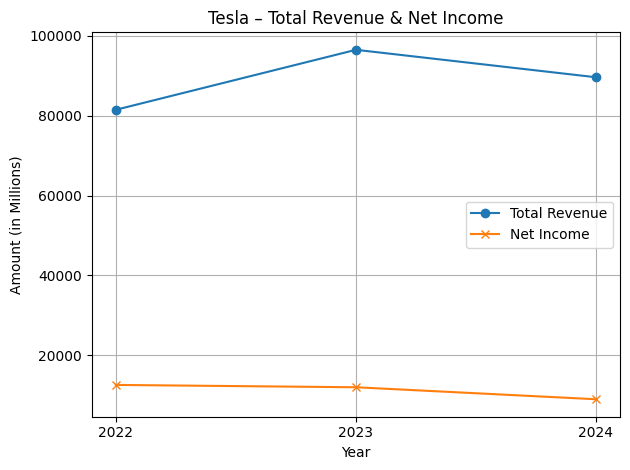

In [13]:
tesla = df[df['Company'] == 'Tesla']
tesla['Year'] = tesla['Year'].astype(int)

plt.plot(tesla['Year'], tesla['Total Revenue'], marker='o', label='Total Revenue')
plt.plot(tesla['Year'], tesla['Net Income'], marker='x', label='Net Income')
plt.title("Tesla – Total Revenue & Net Income")
plt.xlabel("Year")
plt.ylabel("Amount (in Millions)")
plt.xticks(tesla['Year'])  # Yılları düzgün göster
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Microsoft:

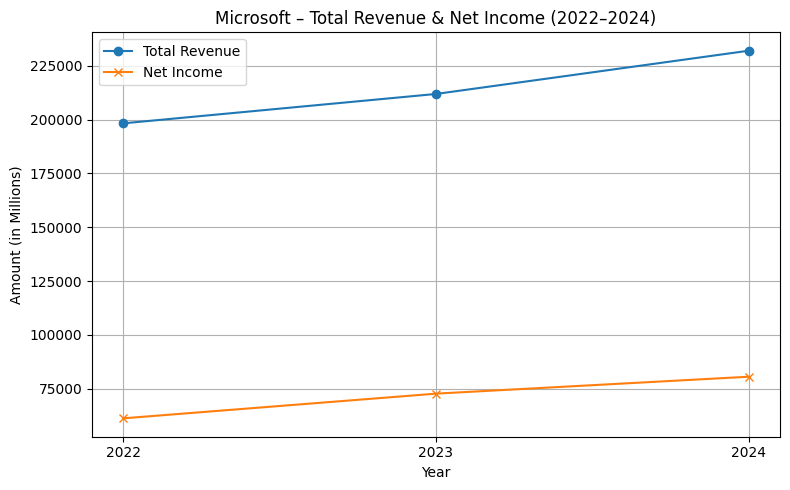

In [10]:
msft = df[df['Company'] == 'Microsoft']
plt.figure(figsize=(8, 5))

plt.plot(msft['Year'], msft['Total Revenue'], marker='o', label='Total Revenue')
plt.plot(msft['Year'], msft['Net Income'], marker='x', label='Net Income')

plt.title("Microsoft – Total Revenue & Net Income (2022–2024)")
plt.xlabel("Year")
plt.ylabel("Amount (in Millions)")
plt.xticks(msft['Year'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ✅ Conclusion

This analysis successfully demonstrates how structured financial data from 10-K filings can be used to:
- Detect trends and business shifts across years
- Provide concise, insightful summaries
- Support financial intelligence tools like AI chatbots

The combination of **data engineering + analysis + visualization** creates a strong foundation for real-world decision-making systems.

> Next step: Use these insights to train a GenAI-powered financial assistant!
